In [1]:
import matplotlib.pyplot as plt

In [2]:
from TALLRec.test_data_loading import *

In [3]:
from transformers import AutoTokenizer 

/home/sairamv/anaconda3/lib/python3.8/site-packages/setuptools/distutils_patch.py:25: UserWarning: Distutils was imported before Setuptools. This usage is discouraged and may exhibit undesirable behaviors or errors. Please use Setuptools' objects directly or at least import Setuptools first.
  warnings.warn(


In [4]:
from tqdm import tqdm

In [5]:
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-3.2-1B')
eval_loader, _ = get_attack_loader(
        tokenizer, 
        sample_numbers=100,  # Load test set since 100 is #candidate items
        dataset='beauty', 
        data_path='data/', 
        batch_size=100, 
        workers=0,
        local_rank=2
    )

Amazon Test Dataset Loader Here!
Dataset:  beauty
compute_datum_info
[INFO] Dataset Size: 2236300, DataLoader Size: 22363


In [6]:
tokenizer.padding_side = "left"  # Allow batched inference
tokenizer.pad_token_id = 0

In [7]:
id_lens = []
for step, batch in tqdm(enumerate(eval_loader)):
    id_lens.append(batch['input_ids'].size()[1])

0it [00:00, ?it/s]/data2/sairamv/LLM-Pop-Bias/TALLRec/test_data_loading.py:217: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "input_ids": torch.tensor(tokenized_full_prompt["input_ids"], dtype=torch.long),
/data2/sairamv/LLM-Pop-Bias/TALLRec/test_data_loading.py:218: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "attention_mask": torch.tensor(tokenized_full_prompt["attention_mask"], dtype=torch.long),
3it [00:00, 21.59it/s]

OUTDICT:  {'input_ids': tensor([[128000,  39314,    374,    459,   7754,    430,  16964,    264,   3465,
             11,  35526,    449,    459,   1988,    430,   5825,   4726,   2317,
             13,   9842,    264,   2077,    430,  36001,  45695,    279,   1715,
            382,  14711,  30151,    512,     32,   1217,    706,   2728,   1579,
          18594,    311,    279,   2768,   3956,     13,   2009,   4453,    279,
           2038,    311,   7168,   3508,    279,   1217,   1053,   4774,    279,
           2218,   2027,     30,    220,  22559,    449,    330,   9642,      1,
            477,    330,   2822,   3343,  40633,    449,   7041,    832,   3492,
            323,    912,   5217,   1495,    382,  14711,   5688,    512,   1502,
          49905,     25,    330,     46,   1932,  75528,  55141,  16339,     11,
           4567,   1195,    323,   1443,  19519,     11,    220,     15,     13,
             20,     12,  71066,    507,  97793,    498,    330,     46,   1932,
    

22363it [17:31, 21.27it/s]


In [9]:
import numpy as np

In [10]:
def print_distribution_stats(distribution, title="Token Length Distribution", bins=50, save_path="length_dist.png"):
    dist = np.array(distribution)

    print(f"\n📊 {title}")
    print(f"Total Samples: {len(dist)}")
    print(f"Min Length   : {np.min(dist)}")
    print(f"Max Length   : {np.max(dist)}")
    print(f"Mean         : {np.mean(dist):.2f}")
    print(f"Median       : {np.median(dist)}")
    print(f"Std Dev      : {np.std(dist):.2f}")
    print(f"90th %ile    : {np.percentile(dist, 90)}")
    print(f"95th %ile    : {np.percentile(dist, 95)}")
    print(f"99th %ile    : {np.percentile(dist, 99)}")

In [11]:
print_distribution_stats(id_lens)


📊 Token Length Distribution
Total Samples: 22363
Min Length   : 171
Max Length   : 5000
Mean         : 372.37
Median       : 317.0
Std Dev      : 237.92
90th %ile    : 506.0
95th %ile    : 662.8999999999978
99th %ile    : 1384.380000000001


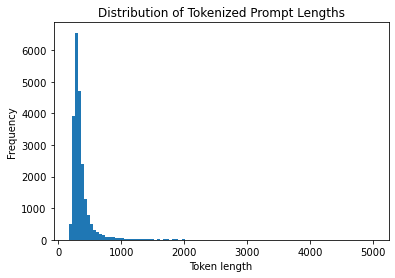

In [8]:
plt.hist(id_lens, bins=100)
plt.title("Distribution of Tokenized Prompt Lengths")
plt.xlabel("Token length")
plt.ylabel("Frequency")
plt.show()